## Modelo ML

En esta sección la idea es construir un modelo simple de Machine Learning para predecir churn de usuarios utilizando variables de comportamiento recientes calculadas sobre una ventana móvil de 30 días. Para ello se entrenarán dos modelos baseline:

* Logistic Regression
* Random Forest

y posteriormente se evaluará su desempeño mediante métricas de clasificación (F1 Score y ROC AUC) y se analizará la relevancia de las variables utilizadas.

In [2]:
#Descarga de librerias necesarias

import pandas as pd
import numpy as np

In [3]:
#Leer el archivo y visualizarlo

df = pd.read_csv("Dataset_Pruebas.csv")

df.head()

,user_id,age,country,events_last_30d,purchases_last_30d,total_spend_last_30d,churned
0,1,40,MX,46,3,24.461384,0
1,2,33,CL,57,4,39.683693,0
2,3,42,MX,52,6,75.392918,0
3,4,53,CL,41,7,181.208986,0
4,5,32,CL,45,4,31.608351,0


##### Preparación de datos

Antes del entrenamiento se aplicaron transformaciones básicas de limpieza y preparación derivadas del análisis exploratorio:

eliminación de edades inválidas (age < 0 o age > 100),
eliminación de actividad extrema (events_last_30d > 10.000),
exclusión de valores negativos en gasto,
y eliminación de registros duplicados.

Aunque durante el EDA se consideró preservar ciertos outliers mediante variables derivadas (por ejemplo refunds o actividad sospechosa), para este baseline inicial se priorizó un pipeline simple y robusto debido al tamaño reducido del dataset y al objetivo exploratorio del ejercicio.

La variable categórica country fue transformada mediante LabelEncoder.

Adicionalmente, se aplicó StandardScaler únicamente para Logistic Regression debido a la sensibilidad de modelos lineales a diferencias de escala entre variables.
Random Forest no requiere normalización por estar basado en árboles de decisión.

Finalmente, se utilizó class_weight='balanced' para compensar el desbalance de clases observado (~90/10

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_model = df.copy()

# Eliminar edades inválidas
df_model = df_model[
    (df_model["age"] >= 0) &
    (df_model["age"] <= 100)
]

# Eliminar actividad extrema
df_model = df_model[
    df_model["events_last_30d"] <= 10000
]

# Eliminar spend negativo
df_model = df_model[
    df_model["total_spend_last_30d"] >= 0
]

# Eliminar duplicados
df_model = df_model.drop_duplicates()

# Features y target

features = [
    "age",
    "country",
    "events_last_30d",
    "purchases_last_30d",
    "total_spend_last_30d"
]

target = "churned"

X = df_model[features]
y = df_model[target]

# Encoding variable categórica

le = LabelEncoder()

X["country"] = le.fit_transform(X["country"])

# Train / Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Escalamiento (solo Logistic Regression)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verificación

print("Shape original:", df.shape)
print("Shape limpio:", df_model.shape)

print("\nDistribución target:")
print(y.value_counts(normalize=True))

Shape original: (2020, 7)
Shape limpio: (1991, 7)

Distribución target:
churned
0    0.903566
1    0.096434
Name: proportion, dtype: float64


C:\Users\dshar\AppData\Local\Temp\ipykernel_20292\3418969861.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["country"] = le.fit_transform(X["country"])


### Entrenamiento del modelo ML

##### Logistic Regression

Como baseline inicial se entrena un modelo de Logistic Regression debido a su simplicidad, interpretabilidad y bajo costo computacional. Este tipo de modelo resulta útil como referencia inicial para entender si las variables disponibles contienen señal predictiva suficiente para explicar churn.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score
)

# Logistic Regression
log_model = LogisticRegression(
    class_weight='balanced',
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

# Predicciones
y_pred_log = log_model.predict(X_test_scaled)

y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

# Métricas

f1_log = f1_score(y_test, y_pred_log)

auc_log = roc_auc_score(y_test, y_prob_log)

print("F1 Score:", round(f1_log,4))
print("ROC AUC:", round(auc_log,4))

print("\nClassification Report")
print(classification_report(y_test, y_pred_log))

F1 Score: 0.1674
ROC AUC: 0.4999

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.53      0.67       361
           1       0.10      0.50      0.17        38

    accuracy                           0.53       399
   macro avg       0.51      0.51      0.42       399
weighted avg       0.83      0.53      0.62       399



#### Random Forest

Posteriormente se entrenó un modelo Random Forest para evaluar si un algoritmo no lineal podía capturar relaciones más complejas entre las variables y mejorar el desempeño predictivo.

In [6]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

# Métricas
f1_rf = f1_score(y_test, y_pred_rf)

auc_rf = roc_auc_score(y_test, y_prob_rf)

print("F1 Score:", round(f1_rf,4))
print("ROC AUC:", round(auc_rf,4))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

F1 Score: 0.0698
ROC AUC: 0.5139

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       361
           1       0.06      0.08      0.07        38

    accuracy                           0.80       399
   macro avg       0.48      0.48      0.48       399
weighted avg       0.82      0.80      0.81       399



### Comparación de modelos

Los resultados obtenidos nos muestran un desempeño limitado en ambos modelos, con métricas cercanas al azar (ROC AUC = 0.5) lo que nos sugiere que las variables disponibles contienen poca señal predictiva real para explicar churn de manera robusta.

* Logistic Regression logró mayor recall sobre la clase churn, aunque con baja precisión y alto número de falsos positivos.
* Random Forest obtuvo un accuracy mayor, pero con escasa capacidad para identificar correctamente usuarios churn.

Este comportamiento resulta consistente con el análisis exploratorio previo, donde se observaron correlaciones lineales muy débiles entre las variables numéricas y la variable objetivo.

In [9]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "F1 Score": [f1_log, f1_rf],
    "ROC AUC": [auc_log, auc_rf]
})

results

,Model,F1 Score,ROC AUC
0,Logistic Regression,0.167401,0.499854
1,Random Forest,0.069767,0.513923


#### Importancia de variables

En ambos modelos, las variables con mayor relevancia fueron: events_last_30d, total_spend_last_30d y purchases_last_30d, esto sugiere que el comportamiento reciente del usuario posee mayor capacidad explicativa que variables demográficas como país o edad pero la señal predictiva general continúa siendo baja.


Logistic Regression

In [10]:
log_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_model.coef_[0]
})

log_importance = log_importance.sort_values(
    by="Coefficient",
    ascending=False
)

log_importance

,Feature,Coefficient
2,events_last_30d,0.162427
4,total_spend_last_30d,0.097413
3,purchases_last_30d,0.072780
0,age,0.053498
1,country,0.023446


Random Forest

In [11]:
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

rf_importance

,Feature,Importance
4,total_spend_last_30d,0.306237
0,age,0.241176
2,events_last_30d,0.229243
3,purchases_last_30d,0.165510
1,country,0.057834


La siguiente grafica nos sugiere que el comportamiento reciente del usuario tiene mayor influencia sobre la predicción de churn que factores geográficos. Particularmente: el gasto reciente, la activida y ciertas características demográficas parecen aportar más información al modelo.  Sin embargo, aunque algunas variables muestran mayor importancia relativa, el desempeño general continúa siendo bajo, indicando que estas señales no son suficientes para discriminar correctamente entre usuarios churn y no churn.

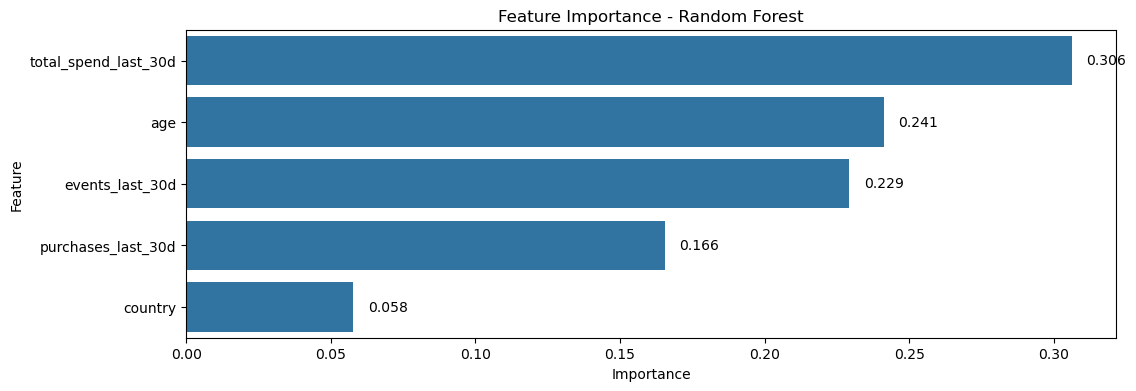

In [16]:
plt.figure(figsize=(12,4))

ax = sns.barplot(
    data=rf_importance,
    x="Importance",
    y="Feature"
)

# Agregar etiquetas de datos
for i, v in enumerate(rf_importance["Importance"]):
    ax.text(
        v + 0.005,      # posición horizontal
        i,              # posición vertical
        f"{v:.3f}",     # formato del texto
        va='center'
    )

plt.title("Feature Importance - Random Forest")

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

La gráfica de comparación muestra que ambos modelos presentan un desempeño limitado para predecir churn.

Logistic Regression
* Obtuvo el mejor F1 Score (0.167).
* Logró identificar una mayor proporción de usuarios churn.
* Sin embargo, el modelo genera una gran cantidad de falsos positivos, lo que reduce significativamente la precisión.

Random Forest
* Presentó un ROC AUC ligeramente superior (0.514).
* A pesar de ello, su capacidad para detectar usuarios churn fue muy baja (F1 0.07).

Hallazgo principal: Ambos modelos presentan métricas cercanas al azar (AUC = 0.5), lo que sugiere que las variables disponibles contienen poca señal predictiva real para explicar churn. Esto resulta consistente con el análisis exploratorio realizado previamente, donde se observaron correlaciones débiles entre las variables y la variable objetivo.

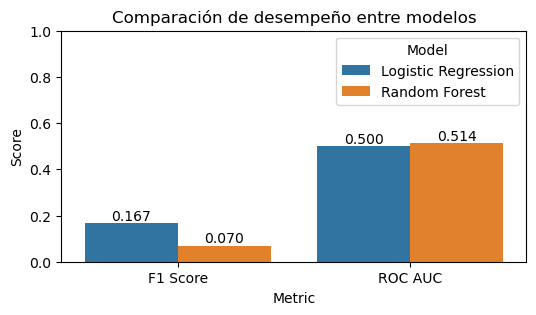

In [22]:

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "F1 Score": [f1_log, f1_rf],
    "ROC AUC": [auc_log, auc_rf]
})

results_melted = results.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(6,3))

ax = sns.barplot(
    data=results_melted,
    x="Metric",
    y="Score",
    hue="Model"
)

# Etiquetas
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.ylim(0,1)

plt.title("Comparación de desempeño entre modelos")

plt.show()

Análisis — Confusion Matrix (Logistic Regression)

De acuerdo con lo que vemos acontinuación el modelo logró detectar aproximadamente el 50% de los usuarios churn (19/38), lo cual es relativamente positivo considerando el desbalance de clases. Sin embargo, para lograrlo generó una gran cantidad de falsos positivos (170 usuarios clasificados erróneamente como churn).

Dependiendo del contexto, este comportamiento podría ser aceptable si el costo de perder un cliente es más alto que contactar usuarios adicionales de forma preventiva.

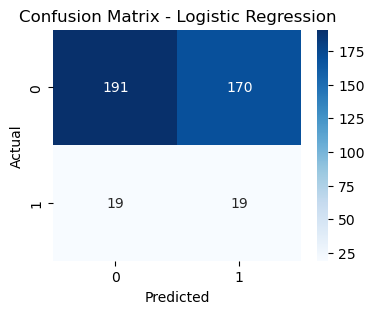

In [23]:
from sklearn.metrics import confusion_matrix

cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(4,3))

sns.heatmap(
    cm_log,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Logistic Regression")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Análisis — Confusion Matrix (Random Forest)

La matriz de confusión de Random Forest muestra un comportamiento mucho más conservador, donde el modelo prioriza clasificar usuarios como “no churn”, lo que mejora el accuracy general (~80%), pero reduce drásticamente la capacidad para detectar churn real. Esto genera muy bajo recall (~0.08) y pérdida de la mayoría de usuarios churn.

Aunque el accuracy parece alto, este resultado es engañoso debido al fuerte desbalance de clases (~90/10). En problemas de churn, detectar correctamente usuarios en riesgo suele ser más importante que maximizar accuracy general.

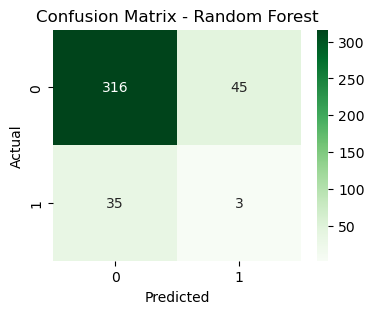

In [24]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(4,3))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Confusion Matrix - Random Forest")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

##	Limitaciones del modelo

Los resultados obtenidos muestran un desempeño limitado (ROC AUC = 0.5), indicando que el modelo posee baja capacidad para diferenciar usuarios churn y no churn de manera robusta.

1. Señal predictiva insuficiente: Las variables disponibles corresponden únicamente a métricas agregadas de comportamiento reciente sobre una ventana móvil de 30 días. Aunque variables como actividad, gasto y compras recientes aportan cierta información, no parecen capturar adecuadamente las causas reales del churn. Esto explica que el desempeño del modelo sea cercano a un clasificador aleatorio.

2. Desbalance de clases: El dataset presenta aproximadamente un 9.5% de usuarios churn, generando un problema de clasificación desbalanceada. En este contexto, métricas como accuracy pueden resultar engañosas, ya que un modelo que prediga siempre “no churn” alcanzaría aproximadamente 90% de exactitud. Por esta razón, se priorizó el análisis mediante F1 Score, Recall y ROC AUC.

3. Ausencia de variables históricas y contextuales: El dataset no incluye variables que normalmente poseen alta capacidad predictiva en problemas reales de churn, tales como: tendencia temporal de actividad, tiempo desde la última compra,tipo de plan, antigüedad del usuario,canal de adquisición, interacciones con soporte,satisfacción/NPS,
o historial de incidencias. La ausencia de este contexto limita significativamente la capacidad explicativa del modelo.

4. Limitaciones del esquema rolling window: Las variables representan snapshots agregados de los últimos 30 días, lo cual simplifica excesivamente la evolución temporal del comportamiento del usuario. Esto puede ocultar patrones importantes como:
caída progresiva de actividad,reducción de engagement o cambios recientes de comportamiento.

## Riesgo de data leakage

Aunque no se identificó leakage explícito en las variables disponibles, existen múltiples riesgos potenciales asociados a la naturaleza temporal del dataset.

1. Duplicación de registros: Durante el EDA se identificó un usuario duplicado (user_id = 866).Si registros duplicados aparecen tanto en entrenamiento como en prueba, el modelo podría memorizar usuarios específicos en lugar de aprender patrones generalizables.

2. Leakage temporal: El principal riesgo proviene del esquema rolling window por ejemplo: si el target churned fue definido como “canceló en los próximos días”,
y las variables incluyen actividad ocurrida dentro de esa misma ventana futura, el modelo estaría utilizando información que no estaría disponible en el momento real de predicción y esto produciría métricas artificialmente optimistas.

3. Variables proxy del churn: Algunas variables podrían representar consecuencias del churn y no causas reales, podrían reflejar usuarios que ya abandonaron la plataforma, generando leakage indirecto.

## Plan de mejora en producción (7 días)

Si este modelo fuera llevado a producción, priorizaría inicialmente la validación y mitigación de posibles riesgos de data leakage temporal, asegurando una correcta separación entre ventanas históricas y período objetivo. Posteriormente, incorporaría nuevas variables de comportamiento histórico como tendencias de actividad, recency y métricas de engagement, además de probar modelos más robustos como XGBoost o LightGBM con optimización de hiperparámetros y ajuste de thresholds para el desbalance de clases. Finalmente, implementaría validación temporal (time-based split), monitoreo de drift y un servicio de scoring simple para simular un entorno real de producción.